In [1]:
list.of.packages <- c("tidyverse","fixest","stargazer","data.table","broom")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


L

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

bin_ref_T <-"17,21]"

In [3]:
varT <- "T_i30_bin"

dict <- setNames(paste0("T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))

# Regression dataframe

In [4]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [5]:
df_reg_women <- df_women %>%
                    mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels))%>%
                    mutate_at(vars(Diet_milk_curd_daily:Diet_aerated_drinks_never), .funs = list(~ . * 1000))

# One month of exposure

## Temperature - daily diet

In [6]:
reg_milk_d <- feols(Diet_milk_curd_daily ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [7]:
reg_pulses_d <- feols(Diet_pulses_beans_daily ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [8]:
reg_green_veg_d <- feols(Diet_green_veg_daily ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [9]:
reg_fruits_d <- feols(Diet_fruits_daily ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [10]:
reg_eggs_d <- feols(Diet_eggs_daily ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [11]:
reg_chicken_meat_d <- feols(Diet_chicken_meat_daily ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [12]:
reg_fish_d <- feols(Diet_fish_daily ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [13]:
reg_fried_food_d <- feols(Diet_fried_food_daily ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [14]:
reg_aerated_drinks_d <- feols(Diet_aerated_drinks_daily ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [15]:
etable(reg_milk_d,reg_pulses_d,reg_green_veg_d,reg_fruits_d,reg_eggs_d,reg_chicken_meat_d,
       reg_fish_d,reg_fried_food_d,reg_aerated_drinks_d,
       tex=TRUE,
       dict=c(dict,
              Diet_milk_curd_daily="Milk, curd",
              Diet_pulses_beans_daily="Pulses, beans",
              Diet_green_veg_daily="Green vegetables",
              Diet_fruits_daily="Fruits",
              Diet_eggs_daily="Eggs",
              Diet_chicken_meat_daily="Meat",
              Diet_fish_daily="Fish",
              Diet_fried_food_daily="Fried food",
              Diet_aerated_drinks_daily="Aerated drinks"
             ),
       fitstat = ~ n + r2 + my,
       drop="%!T_i30_bin")

\begingroup
\centering
\begin{tabular}{lccccccccc}
   \tabularnewline \midrule \midrule
   Dependent Variables:           & Milk, curd & Pulses, beans & Green vegetables & Fruits      & Eggs          & Meat    & Fish          & Fried food & Aerated drinks\\  
   Model:                         & (1)        & (2)           & (3)              & (4)         & (5)           & (6)     & (7)           & (8)        & (9)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & 8.181      & 17.82$^{**}$  & 14.13            & 3.850       & 3.375         & -1.784  & 0.5786        & -4.679     & -4.512\\   
                                  & (10.55)    & (7.937)       & (11.90)          & (5.509)     & (2.399)       & (2.286) & (2.602)       & (4.809)    & (3.178)\\   
   T: (21,23]                     & 5.311      & 12.33         & 12.51            & 9.455$^{*}$ & -1.873        & -0.5795 & 5.858$^{*}$   & 4.069      & -0.5948\\   
                                  & (7.385)    &

## Temperature - weekly diet

In [16]:
reg_milk_w <- feols(Diet_milk_curd_week ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [17]:
reg_pulses_w <- feols(Diet_pulses_beans_week ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [18]:
reg_green_veg_w <- feols(Diet_green_veg_week ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [19]:
reg_fruits_w <- feols(Diet_fruits_week ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [20]:
reg_eggs_w <- feols(Diet_eggs_week ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [21]:
reg_chicken_meat_w <- feols(Diet_chicken_meat_week ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [22]:
reg_fish_w <- feols(Diet_fish_week ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [23]:
reg_fried_food_w <- feols(Diet_fried_food_week ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [24]:
reg_aerated_drinks_w <- feols(Diet_aerated_drinks_week ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [25]:
etable(reg_milk_w,reg_pulses_w,reg_green_veg_w,reg_fruits_w,reg_eggs_w,reg_chicken_meat_w,
       reg_fish_w,reg_fried_food_w,reg_aerated_drinks_w,
       tex=TRUE,
       dict=c(dict,
              Diet_milk_curd_daily="Milk, curd",
              Diet_pulses_beans_daily="Pulses, beans",
              Diet_green_veg_daily="Green vegetables",
              Diet_fruits_daily="Fruits",
              Diet_eggs_daily="Eggs",
              Diet_chicken_meat_daily="Meat",
              Diet_fish_daily="Fish",
              Diet_fried_food_daily="Fried food",
              Diet_aerated_drinks_daily="Aerated drinks"
             ),
       fitstat = ~ n + r2 + my,
       drop="%!T_i30_bin")

\begingroup
\centering
\begin{tabular}{lccccccccc}
   \tabularnewline \midrule \midrule
   Dependent Variables:           & Diet\_milk\_curd\_week    & Diet\_pulses\_beans\_week    & Diet\_green\_veg\_week    & Diet\_fruits\_week   & Diet\_eggs\_week   & Diet\_chicken\_meat\_week    & Diet\_fish\_week   & Diet\_fried\_food\_week    & Diet\_aerated\_drinks\_week\\     
   Model:                         & (1)                       & (2)                          & (3)                       & (4)                  & (5)                & (6)                          & (7)                & (8)                        & (9)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & 5.951                     & -14.35                       & -4.953                    & -0.2680              & 12.99$^{*}$        & 11.78$^{*}$                  & 0.9373             & 3.863                      & 11.01\\   
                                  & (6.343)                   & (9.057)         

## Temperature - occasionnally diet

In [26]:
reg_milk_o <- feols(Diet_milk_curd_oc ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [27]:
reg_pulses_o <- feols(Diet_pulses_beans_oc ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [28]:
reg_green_veg_o <- feols(Diet_green_veg_oc ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [29]:
reg_fruits_o <- feols(Diet_fruits_oc ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [30]:
reg_eggs_o <- feols(Diet_eggs_oc ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [31]:
reg_chicken_meat_o <- feols(Diet_chicken_meat_oc ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [32]:
reg_fish_o <- feols(Diet_fish_oc ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [33]:
reg_fried_food_o <- feols(Diet_fried_food_oc ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [34]:
reg_aerated_drinks_o <- feols(Diet_aerated_drinks_oc ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [35]:
etable(reg_milk_o,reg_pulses_o,reg_green_veg_o,reg_fruits_o,reg_eggs_o,reg_chicken_meat_o,
       reg_fish_o,reg_fried_food_o,reg_aerated_drinks_o,
       tex=TRUE,
       dict=c(dict,
              Diet_milk_curd_daily="Milk, curd",
              Diet_pulses_beans_daily="Pulses, beans",
              Diet_green_veg_daily="Green vegetables",
              Diet_fruits_daily="Fruits",
              Diet_eggs_daily="Eggs",
              Diet_chicken_meat_daily="Meat",
              Diet_fish_daily="Fish",
              Diet_fried_food_daily="Fried food",
              Diet_aerated_drinks_daily="Aerated drinks"
             ),
       fitstat = ~ n + r2 + my,
       drop="%!T_i30_bin")

\begingroup
\centering
\begin{tabular}{lccccccccc}
   \tabularnewline \midrule \midrule
   Dependent Variables:           & Diet\_milk\_curd\_oc    & Diet\_pulses\_beans\_oc    & Diet\_green\_veg\_oc    & Diet\_fruits\_oc   & Diet\_eggs\_oc   & Diet\_chicken\_meat\_oc    & Diet\_fish\_oc   & Diet\_fried\_food\_oc    & Diet\_aerated\_drinks\_oc\\     
   Model:                         & (1)                     & (2)                        & (3)                     & (4)                & (5)              & (6)                        & (7)              & (8)                      & (9)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & -12.63                  & -3.475                     & -8.733                  & -4.889             & 1.106            & 10.15                      & 10.19            & -3.187                   & -21.35$^{*}$\\   
                                  & (7.934)                 & (6.230)                    & (5.373)                 & (8.537

## Temperature - never diet

In [36]:
reg_milk_n <- feols(Diet_milk_curd_never ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [37]:
reg_pulses_n <- feols(Diet_pulses_beans_never ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [38]:
reg_green_veg_n <- feols(Diet_green_veg_never ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [39]:
reg_fruits_n <- feols(Diet_fruits_never ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [40]:
reg_eggs_n <- feols(Diet_eggs_never ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [41]:
reg_chicken_meat_n <- feols(Diet_chicken_meat_never ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [42]:
reg_fish_n <- feols(Diet_fish_never ~  i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [43]:
reg_fried_food_n <- feols(Diet_fried_food_never ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [44]:
reg_aerated_drinks_n <- feols(Diet_aerated_drinks_never ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 + 
                                                Current_age + N_year_educ + 
                                                Smoker + Health_insurance  +
                                                Religion_muslim + Religion_not_hindu_nor_muslim +
                                                Ethni_SC + Ethni_ST + Ethni_OBC +
                                                Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                                Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
              df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [45]:
etable(reg_milk_n,reg_pulses_n,reg_green_veg_n,reg_fruits_n,reg_eggs_n,reg_chicken_meat_n,
       reg_fish_n,reg_fried_food_n,reg_aerated_drinks_n,
       tex=TRUE,
       dict=c(dict,
              Diet_milk_curd_daily="Milk, curd",
              Diet_pulses_beans_daily="Pulses, beans",
              Diet_green_veg_daily="Green vegetables",
              Diet_fruits_daily="Fruits",
              Diet_eggs_daily="Eggs",
              Diet_chicken_meat_daily="Meat",
              Diet_fish_daily="Fish",
              Diet_fried_food_daily="Fried food",
              Diet_aerated_drinks_daily="Aerated drinks"
             ),
       fitstat = ~ n + r2 + my,
       drop="%!T_i30_bin")

\begingroup
\centering
\begin{tabular}{lccccccccc}
   \tabularnewline \midrule \midrule
   Dependent Variables:           & Diet\_milk\_curd\_never    & Diet\_pulses\_beans\_never    & Diet\_green\_veg\_never    & Diet\_fruits\_never   & Diet\_eggs\_never   & Diet\_chicken\_meat\_never    & Diet\_fish\_never   & Diet\_fried\_food\_never    & Diet\_aerated\_drinks\_never\\     
   Model:                         & (1)                        & (2)                           & (3)                        & (4)                   & (5)                 & (6)                           & (7)                 & (8)                         & (9)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & -1.503                     & 0.0063                        & -0.4398                    & 1.307                 & -17.47$^{**}$       & -20.14$^{**}$                 & -11.71              & 4.002                       & 14.85$^{**}$\\   
                                  & (5.442)     

# Extract coefs for plotting

In [46]:
extract_coefs <- function(reg,item,freq){
        coef_tab_estim <- as.data.frame(rbind(tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::<=17°C")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = "≤17°C"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::21,23]")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = "(21,23]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::23,25]")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = "(23,25]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::25,27]")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = "(25,27]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::27,29]")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = "(27,29]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::29,31]")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = "(29,31]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::31,33]")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = "(31,33]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::>33°C")%>% 
                                                 mutate(item = item, 
                                                        specifi= freq,
                                                        label = ">33°C")
                                             ))%>%
                                
                            add_row(term=NA,estimate=0,std.error=NA,statistic=NA,p.value=NA,
                                    conf.low=0,conf.high=0,item=item,specifi=freq,label="(17,21]")
}

In [47]:
coefs_item <- function(label_item,reg_d,reg_w,reg_o,reg_n){
         rbind(extract_coefs(reg_d,label_item,"Daily"),
               extract_coefs(reg_w,label_item,"Weekly"),
               extract_coefs(reg_o,label_item,"Occasionally"),
               extract_coefs(reg_n,label_item,"Never"))%>%
               mutate(label=factor(label,levels=T_bins_labels_pretty),
                      specifi=factor(specifi,levels=c("Daily","Weekly","Occasionally","Never")))
}

In [48]:
coefs_milk <- coefs_item("Milk or curd",reg_milk_d,reg_milk_w,reg_milk_o,reg_milk_n)
coefs_pulses <- coefs_item("Pulses or beans",reg_pulses_d,reg_pulses_w,reg_pulses_o,reg_pulses_n)
coefs_veg <- coefs_item("Dark green, leafy vegetables",reg_green_veg_d,reg_green_veg_w,reg_green_veg_o,reg_green_veg_n)
coefs_fruits <- coefs_item("Fruits",reg_fruits_d,reg_fruits_w,reg_fruits_o,reg_fruits_n)
coefs_eggs <- coefs_item("Eggs",reg_eggs_d,reg_eggs_w,reg_eggs_o,reg_eggs_n)
coefs_meat <- coefs_item("Meat",reg_chicken_meat_d,reg_chicken_meat_w,reg_chicken_meat_o,reg_chicken_meat_n)
coefs_fish <- coefs_item("Fish",reg_fish_d,reg_fish_w,reg_fish_o,reg_fish_n)
coefs_fried_food <- coefs_item("Fried food",reg_fried_food_d,reg_fried_food_w,reg_fried_food_o,reg_fried_food_n)
coefs_aerated_drinks <- coefs_item("Aerated drinks",reg_aerated_drinks_d,reg_aerated_drinks_w,reg_aerated_drinks_o,reg_aerated_drinks_n)

# Plot

In [49]:
all_coefs <- rbind(coefs_milk,coefs_pulses,coefs_veg,coefs_fruits,coefs_eggs,
                   coefs_meat,coefs_fish,coefs_fried_food,coefs_aerated_drinks)

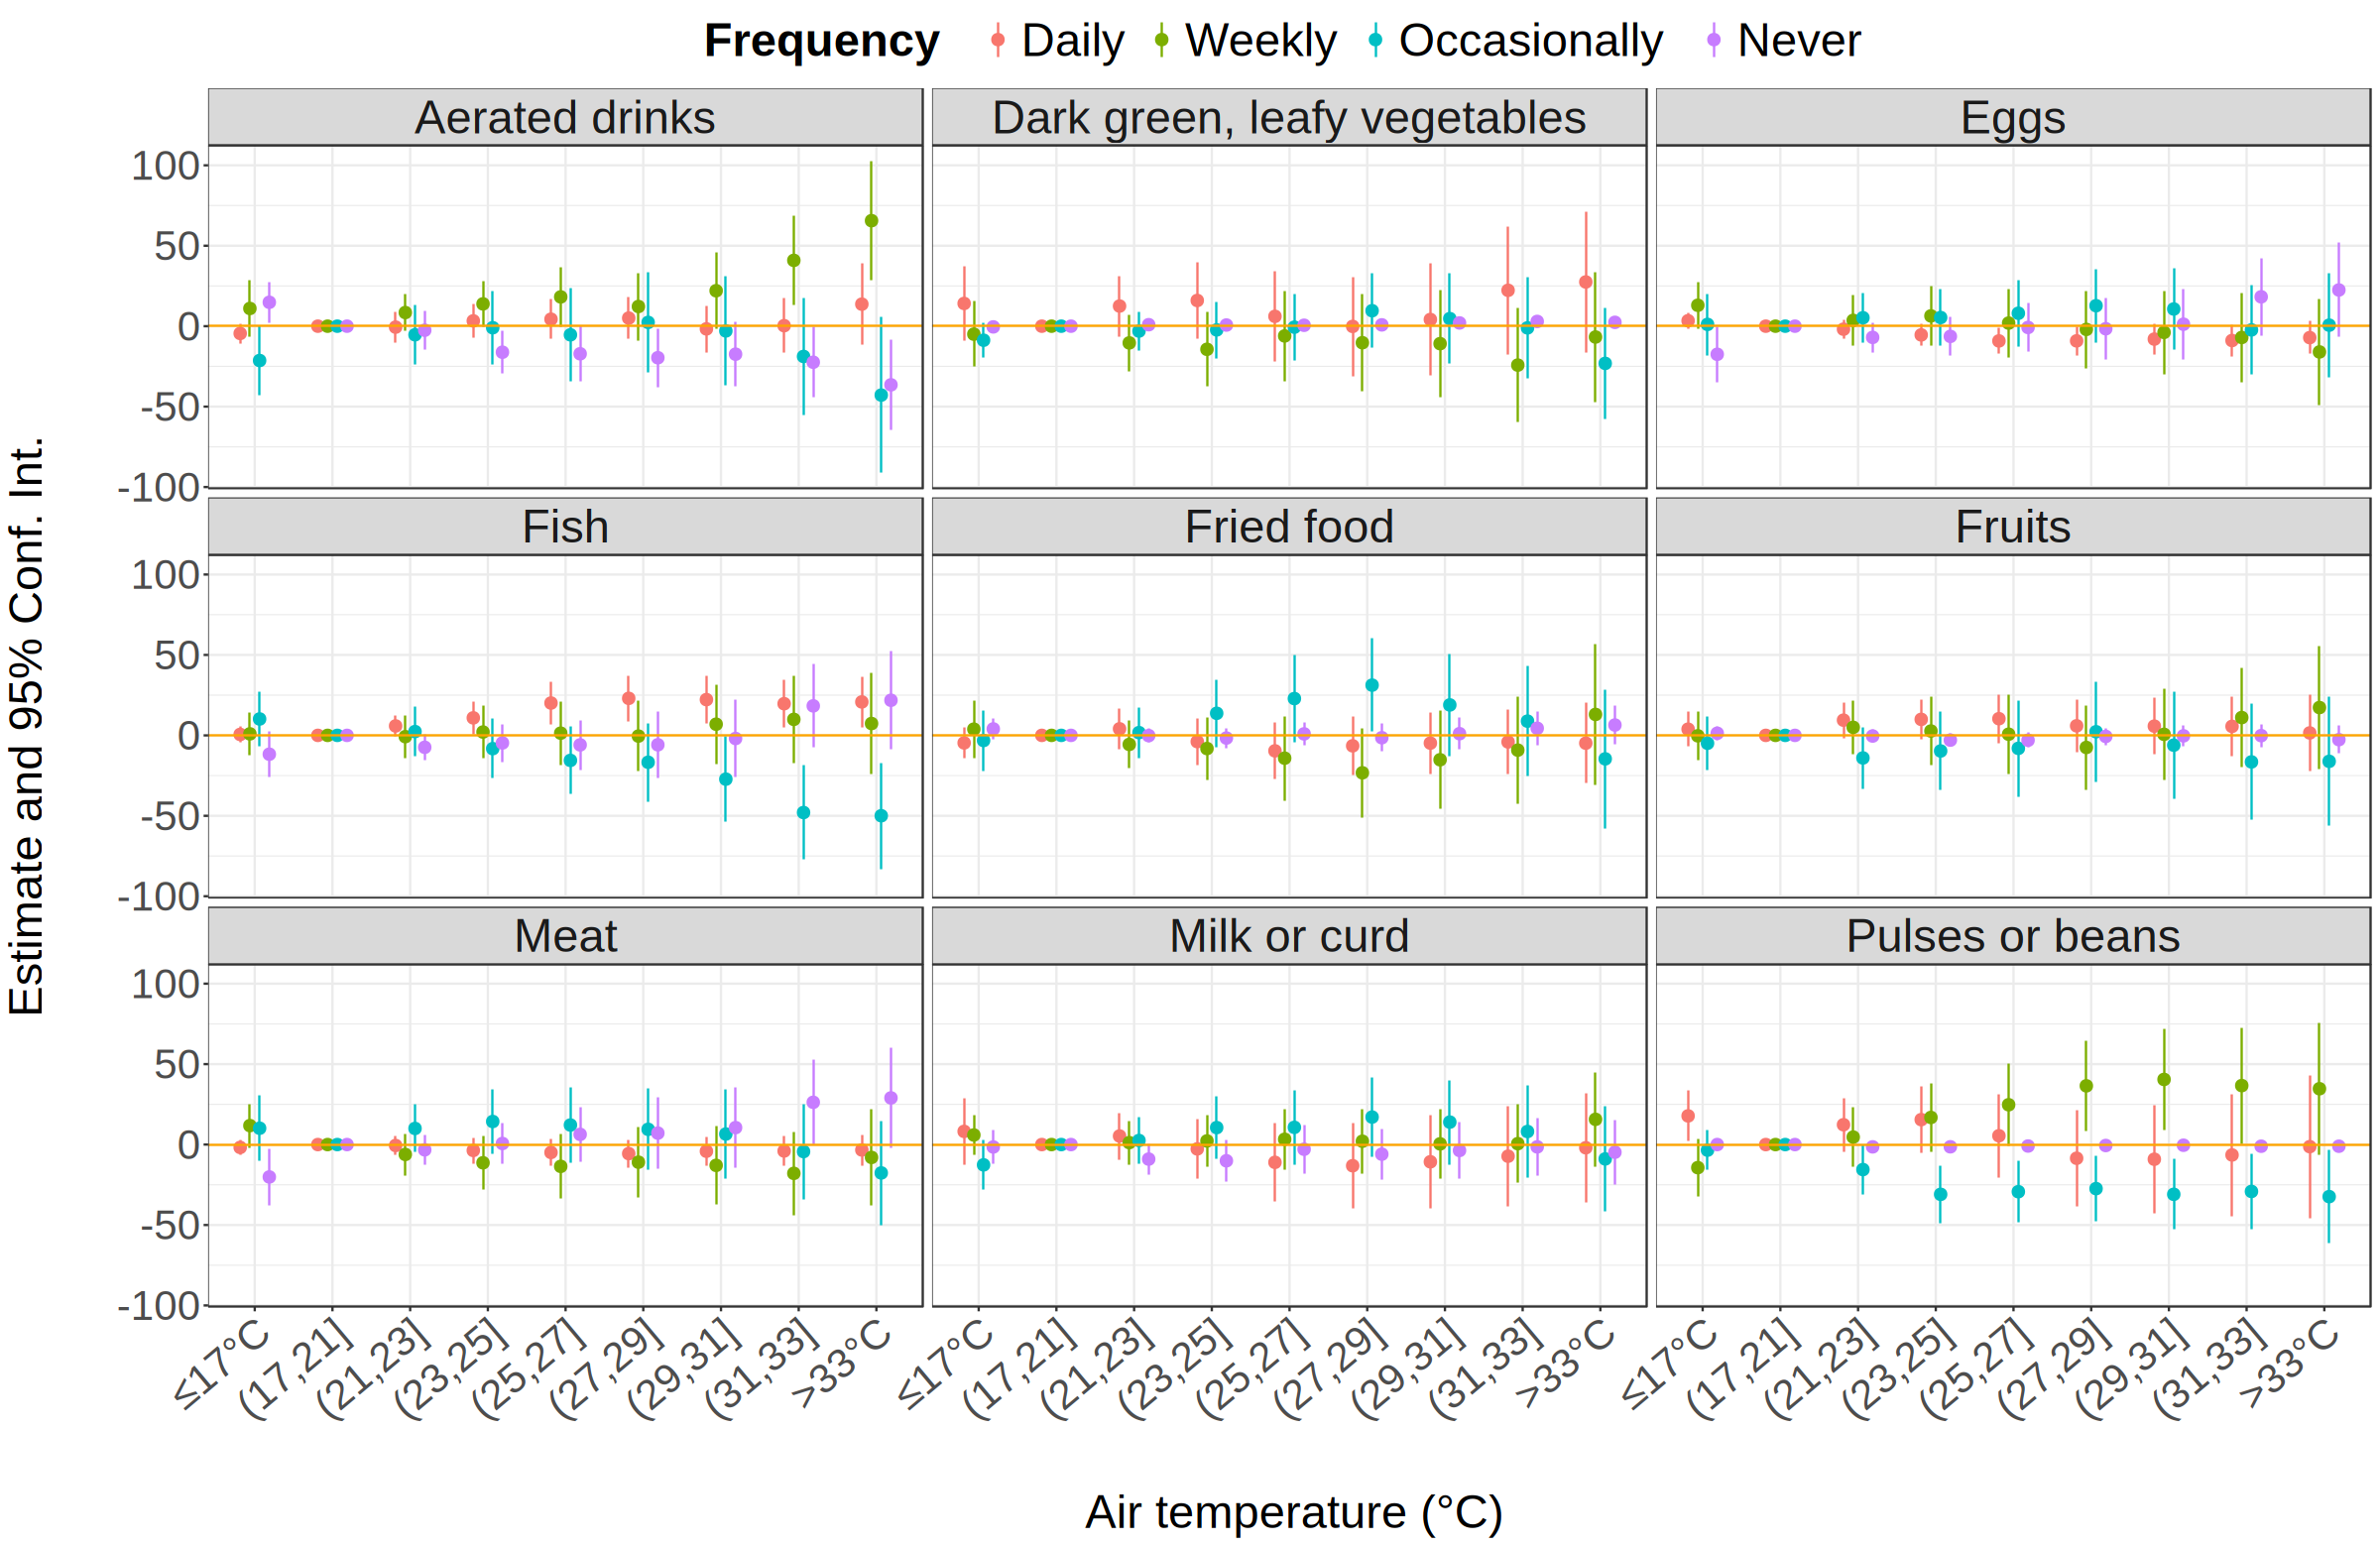

In [50]:
options(repr.plot.width=20, repr.plot.height=13, scipen=9999)

plot_estimates <- ggplot(all_coefs,aes(x=label, y=estimate, ymin=conf.low, ymax=conf.high, color=specifi)) +
                          geom_pointrange(position = position_dodge(width = 1/2)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(#title="Women reported consumption (per 1,000)",subtitle="",
                               x="\n Air temperature (°C)", 
                               y="Estimate and 95% Conf. Int.\n", 
                               color="Frequency")+
                          facet_wrap(~item, nrow=3)+
                          theme_bw() +
                          theme(plot.title = element_text(size = 30, face="bold"),
                                plot.subtitle = element_text(size = 15, face="bold"),
                                legend.position="top",
                                legend.title = element_text(size = 28,face ="bold"),
                                legend.text = element_text(size = 28),
                                strip.text.x = element_text(size = 28),
                                axis.text.x = element_text(size = 25, angle=40, hjust=1),
                                axis.text.y = element_text(size = 25),
                                axis.title.x = element_text(size = 28, hjust = 0.5),
                                axis.title.y = element_text(size = 28, hjust = 0.5))
plot_estimates

In [51]:
ggsave("./3_output/img/women_diets_estimates.png", width=20, height=13, plot_estimates)